In [1]:

import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt


✅ Loaded features: (6686624, 18)
   permno        date       ret  ret_excess  \
0   10104  1986-03-26  0.019108    0.018808   
1   10104  1986-03-27  0.037500    0.037200   

                            securitynm securitytype ticker tradingsymbol  \
0  ORACLE SYSTEMS CORP; COM NONE; CONS         EQTY   ORCL          ORCL   
1          ORACLE CORP; COM NONE; CONS         EQTY   ORCL          ORCL   

   ret_lag1  ret_lag2  ret_lag3  ret_lag4  ret_lag5  ret_excess_lag1  \
0  0.019108  0.000000       0.0 -0.006329 -0.006329         0.018808   
1  0.019108  0.019108       0.0  0.000000 -0.006329         0.018808   

   skew_20d  mean_20d    sd_20d  vol_20d_forward  
0  0.465902 -0.002846  0.021867         0.024209  
1  0.521881 -0.002183  0.022908         0.023919  
✅ Loaded entropy target: (6668854, 3)
   permno        date  entropy_20d_forward
0   10104  1986-04-10             2.646439
1   10104  1986-04-10             2.841446
✅ Merged dataset shape: (13510889, 19)
   permno        dat

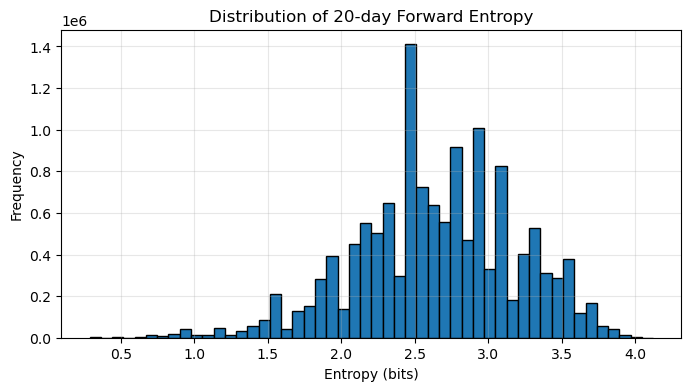

In [2]:

# === 1. Load existing feature file ===
features = pd.read_csv("../data/crsp_features_full_v.txt", sep="\t")
print("✅ Loaded features:", features.shape)
print(features.head(2))

# === 2. Load newly computed entropy target ===
entropy_target = pd.read_csv("../data/entropy_target.txt", sep="\t")
print("✅ Loaded entropy target:", entropy_target.shape)
print(entropy_target.head(2))

# === 3. Merge ===
df_entropy = features.merge(entropy_target, on=["permno", "date"], how="inner")
print("✅ Merged dataset shape:", df_entropy.shape)
print(df_entropy[["permno", "date", "entropy_20d_forward"]].head())

# === 4. Basic statistics ===
summary = df_entropy["entropy_20d_forward"].describe()
print("\n📊 Entropy target summary:\n", summary)

# === 5. Optional: visualize distribution ===
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
df_entropy["entropy_20d_forward"].hist(bins=50, edgecolor='k')
plt.title("Distribution of 20-day Forward Entropy")
plt.xlabel("Entropy (bits)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()
